<a href="https://colab.research.google.com/github/rushinakhale115/NLP_Assignments/blob/main/NLP_Assignments/NLP_Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total sentences: 20
Vocabulary size : 85
Number of labels: 5  ['', 'O', 'PER', 'LOC', 'ORG']
Max sequence len: 6

X shape: (20, 6)
y shape: (20, 6)

Train: (16, 6), Test: (4, 6)



Model: "BiLSTM_NER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_input          │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 6, 64)     │      5,440 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 6)         │          0 │ word_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 6, 128)    │     66,048 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 6, 64)     │     41,216 │ bilstm_1[0][0],   │
│ (Bidirectional)     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_output        │ (None, 6, 5)      │        325 │ bilstm_2[0][0],   │
│ (TimeDistributed)   │                   │            │ not_equal_3[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 113,029 (441.52 KB)

 Trainable params: 113,029 (441.52 KB)

 Non-trainable params: 0 (0.00 B)


Training Bi-LSTM model...
Epoch 1/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 348ms/step - accuracy: 0.3587 - loss: 1.6017 - val_accuracy: 0.5000 - val_loss: 1.5881
Epoch 2/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5435 - loss: 1.5749 - val_accuracy: 0.5000 - val_loss: 1.5638
Epoch 3/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5435 - loss: 1.5419 - val_accuracy: 0.5000 - val_loss: 1.5311
Epoch 4/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5435 - loss: 1.4985 - val_accuracy: 0.5000 - val_loss: 1.4852
Epoch 5/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5435 - loss: 1.4286 - val_accuracy: 0.5000 - val_loss: 1.4211
Epoch 6/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5435 - loss: 1.3363 - val_accuracy: 0.5000 - val_loss: 1.3403
Epoch 7/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5435 - loss: 1.2468 - val_accuracy: 0.5000 - val_loss: 1.2705
Epoch 8/80
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5435 - loss: 1.2102 - val_accuracy


Classification Report (excluding PAD):
              precision    recall  f1-score   support

           O       0.79      1.00      0.88        11
         PER       0.67      0.67      0.67         3
         LOC       1.00      0.60      0.75         5
         ORG       0.50      0.33      0.40         3

    accuracy                           0.77        22
   macro avg       0.74      0.65      0.67        22
weighted avg       0.78      0.77      0.76        22



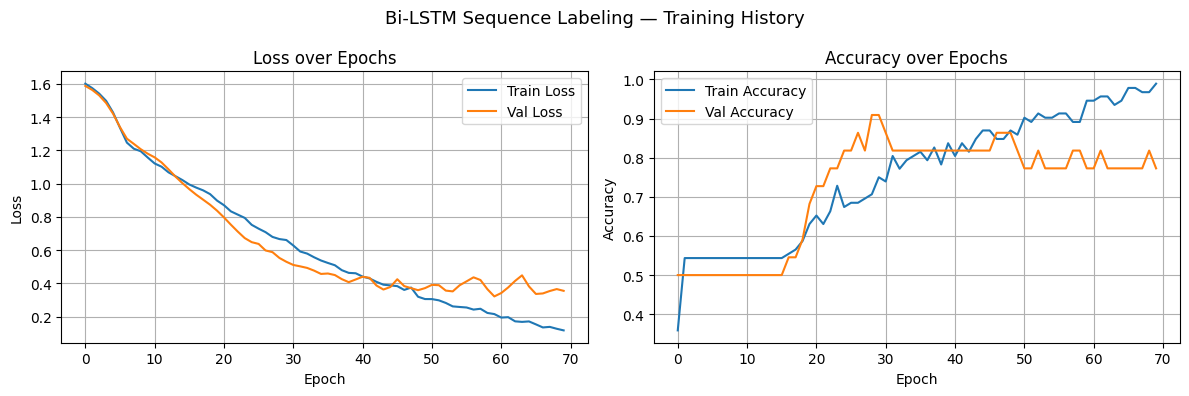

Saved: lstm_training.png

CUSTOM PREDICTION DEMO



Sentence : Elon Musk visited Paris last week
Word            Predicted Label
------------------------------
Elon            PER
Musk            PER
visited         O
Paris           O
last            O
week            LOC

Sentence : Google opened a new office in Berlin
Word            Predicted Label
------------------------------
Google          ORG
opened          O
a               O
new             O
office          O
in              LOC
Berlin          LOC

Sentence : Marie Curie was born in Warsaw
Word            Predicted Label
------------------------------
Marie           PER
Curie           O
was             O
born            O
in              O
Warsaw          LOC

        LSTM SEQUENCE LABELING — SUMMARY
  Task           : Named Entity Recognition (NER)
  Dataset        : Custom (20 sentences)
  Labels         : O, PER, LOC, ORG
  Model          : Bidirectional LSTM (2 layers)
  Embedding Dim  : 64
  LSTM Units     : 64 → 32 (Bidirectional)
  Loss           : Sparse Catego

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# ─── Reproducibility ──────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

# ─── 1. Dataset — Named Entity Recognition (NER) ─────────────────────────────
# Format: list of (sentence_tokens, labels) pairs
# Labels: O=Other, PER=Person, LOC=Location, ORG=Organization

raw_data = [
    (["John",    "lives",  "in",    "New",     "York"],
     ["PER",     "O",      "O",     "LOC",     "LOC"]),

    (["Apple",   "was",    "founded", "by",    "Steve",   "Jobs"],
     ["ORG",     "O",      "O",       "O",     "PER",     "PER"]),

    (["Paris",   "is",     "the",   "capital", "of",      "France"],
     ["LOC",     "O",      "O",     "O",       "O",       "LOC"]),

    (["Google",  "hired",  "Sundar", "Pichai",  "in",     "London"],
     ["ORG",     "O",      "PER",    "PER",     "O",      "LOC"]),

    (["Mary",    "visited", "Berlin", "last",   "summer"],
     ["PER",     "O",       "LOC",    "O",      "O"]),

    (["Microsoft", "opened", "an",   "office",  "in",     "Tokyo"],
     ["ORG",       "O",      "O",    "O",       "O",      "LOC"]),

    (["Barack",  "Obama",  "was",   "born",    "in",      "Hawaii"],
     ["PER",     "PER",    "O",     "O",       "O",       "LOC"]),

    (["Amazon",  "delivers", "to",  "London",  "and",     "Paris"],
     ["ORG",     "O",        "O",   "LOC",     "O",       "LOC"]),

    (["Tesla",   "was",    "founded", "by",    "Elon",    "Musk"],
     ["ORG",     "O",      "O",       "O",     "PER",     "PER"]),

    (["Alice",   "works",  "at",    "NASA",    "in",      "Washington"],
     ["PER",     "O",      "O",     "ORG",     "O",       "LOC"]),

    (["The",     "UN",     "met",   "in",      "Geneva",  "today"],
     ["O",       "ORG",    "O",     "O",       "LOC",     "O"]),

    (["Elon",    "Musk",   "leads", "SpaceX",  "and",     "Tesla"],
     ["PER",     "PER",    "O",     "ORG",     "O",       "ORG"]),

    (["London",  "is",     "home",  "to",      "many",    "banks"],
     ["LOC",     "O",      "O",     "O",       "O",       "O"]),

    (["Facebook", "was",   "created", "by",    "Mark",    "Zuckerberg"],
     ["ORG",      "O",     "O",       "O",     "PER",     "PER"]),

    (["The",     "Nile",   "flows", "through", "Egypt"],
     ["O",       "LOC",    "O",     "O",       "LOC"]),

    (["IBM",     "has",    "offices", "in",    "New",     "Delhi"],
     ["ORG",     "O",      "O",       "O",     "LOC",     "LOC"]),

    (["Serena",  "Williams", "won",  "at",     "Wimbledon"],
     ["PER",     "PER",      "O",    "O",      "LOC"]),

    (["Netflix", "is",     "based", "in",      "California"],
     ["ORG",     "O",      "O",     "O",       "LOC"]),

    (["Gandhi",  "led",    "India", "to",      "independence"],
     ["PER",     "O",      "LOC",   "O",       "O"]),

    (["Twitter", "was",    "bought", "by",     "Elon",    "Musk"],
     ["ORG",     "O",      "O",      "O",      "PER",     "PER"]),
]

print(f"Total sentences: {len(raw_data)}")

# ─── 2. Build Vocabularies ────────────────────────────────────────────────────
# Word vocabulary
all_words  = ["", ""] + sorted(set(w for sent, _ in raw_data for w in sent))
word2idx   = {w: i for i, w in enumerate(all_words)}
idx2word   = {i: w for w, i in word2idx.items()}

# Label vocabulary
all_labels = ["", "O", "PER", "LOC", "ORG"]
label2idx  = {l: i for i, l in enumerate(all_labels)}
idx2label  = {i: l for l, i in label2idx.items()}

VOCAB_SIZE  = len(all_words)
NUM_LABELS  = len(all_labels)
MAX_LEN     = max(len(s) for s, _ in raw_data)   # pad all to same length

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Number of labels: {NUM_LABELS}  {all_labels}")
print(f"Max sequence len: {MAX_LEN}\n")

# ─── 3. Encode & Pad Sequences ───────────────────────────────────────────────
def encode_and_pad(data):
    X, y = [], []
    for words, labels in data:
        # Encode words to indices, unknown words →
        x_seq = [word2idx.get(w, word2idx[""]) for w in words]
        y_seq = [label2idx[l] for l in labels]

        # Pad with 0 () to MAX_LEN
        pad_len = MAX_LEN - len(x_seq)
        x_seq  += [0] * pad_len
        y_seq  += [0] * pad_len

        X.append(x_seq)
        y.append(y_seq)
    return np.array(X), np.array(y)

X, y = encode_and_pad(raw_data)
print(f"X shape: {X.shape}")   # (20, MAX_LEN)
print(f"y shape: {y.shape}\n") # (20, MAX_LEN)

# ─── 4. Train/Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}\n")

# ─── 5. Build Bi-LSTM Model ───────────────────────────────────────────────────
# Embedding → Bi-LSTM → Bi-LSTM → TimeDistributed Dense
# TimeDistributed applies Dense to EVERY timestep (word) independently

def build_bilstm_model():
    inputs = layers.Input(shape=(MAX_LEN,), name="word_input")

    # Embedding: maps word index → dense vector of size 64
    x = layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64,
        mask_zero=True,          # ignore PAD tokens during training
        name="embedding"
    )(inputs)

    # Bidirectional LSTM layer 1 — reads sequence both ways
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.3),
        name="bilstm_1"
    )(x)

    # Bidirectional LSTM layer 2 — deeper representation
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=True, dropout=0.3),
        name="bilstm_2"
    )(x)

    # TimeDistributed Dense — predict label for EACH word position
    outputs = layers.TimeDistributed(
        layers.Dense(NUM_LABELS, activation="softmax"),
        name="label_output"
    )(x)

    model = models.Model(inputs, outputs, name="BiLSTM_NER")
    return model

model = build_bilstm_model()
model.summary()

# ─── 6. Compile & Train ───────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # labels are integers not one-hot
    metrics=["accuracy"]
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=10,
    restore_best_weights=True, verbose=1
)

print("\nTraining Bi-LSTM model...")
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=4,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# ─── 7. Evaluate ──────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# ─── 8. Per-label Classification Report ──────────────────────────────────────
# Flatten predictions, ignore PAD tokens (label index 0)
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_flat  = np.argmax(y_pred_probs, axis=-1).flatten()
y_true_flat  = y_test.flatten()

# Remove PAD positions
mask         = y_true_flat != 0
y_pred_clean = y_pred_flat[mask]
y_true_clean = y_true_flat[mask]

target_names = ["O", "PER", "LOC", "ORG"]   # skip PAD
print("\nClassification Report (excluding PAD):")
print(classification_report(
    y_true_clean, y_pred_clean,
    labels=[1, 2, 3, 4],
    target_names=target_names
))

# ─── 9. Plot Training History ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"],     label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Bi-LSTM Sequence Labeling — Training History", fontsize=13)
plt.tight_layout()
plt.savefig("lstm_training.png", dpi=150)
plt.show()
print("Saved: lstm_training.png")

# ─── 10. Predict on New Sentences ─────────────────────────────────────────────
def predict_sentence(sentence):
    """Predict NER labels for a list of words."""
    tokens = sentence.split()
    x_seq  = [word2idx.get(w, word2idx[""]) for w in tokens]
    pad_len = MAX_LEN - len(x_seq)
    x_seq  += [0] * pad_len
    x_input = np.array([x_seq])

    pred_probs = model.predict(x_input, verbose=0)
    pred_labels = np.argmax(pred_probs, axis=-1)[0]

    print(f"\nSentence : {' '.join(tokens)}")
    print(f"{'Word':<15} {'Predicted Label'}")
    print("-" * 30)
    for word, label_idx in zip(tokens, pred_labels[:len(tokens)]):
        print(f"{word:<15} {idx2label[label_idx]}")

print("\n" + "="*50)
print("CUSTOM PREDICTION DEMO")
print("="*50)
predict_sentence("Elon Musk visited Paris last week")
predict_sentence("Google opened a new office in Berlin")
predict_sentence("Marie Curie was born in Warsaw")

# ─── 11. Summary ──────────────────────────────────────────────────────────────
print("\n" + "="*50)
print("        LSTM SEQUENCE LABELING — SUMMARY")
print("="*50)
print(f"  Task           : Named Entity Recognition (NER)")
print(f"  Dataset        : Custom ({len(raw_data)} sentences)")
print(f"  Labels         : O, PER, LOC, ORG")
print(f"  Model          : Bidirectional LSTM (2 layers)")
print(f"  Embedding Dim  : 64")
print(f"  LSTM Units     : 64 → 32 (Bidirectional)")
print(f"  Loss           : Sparse Categorical Cross-Entropy")
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print("="*50)
